## 0. Load Libraries

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

print(np.__version__)
print(pd.__version__)
print(yf.__version__)

2.2.5
2.3.3
1.2.0


## 1. Load Data

Ten Large US energy-related stocks:
1. Exxon Mobil (XOM)
2. Chevron (CVX)
3. ConocoPhilips (COP)
4. EOG Resources (EOG)
5. Schlumberger (SLB)
6. Phillips 66 (PSX)
7. Valero (VLO)
8. Marathon Petroleum (MPC)
9. Kinder Morgan (KMI)
10. Williams Companies (WMB)

In [25]:
symbols = ["XOM", "CVX", "COP", "EOG", "SLB", "PSX", "VLO", "MPC", "KMI", "WMB"]
benchmark = "XLE"

all_tickers = symbols + [benchmark]

start_date = "2015-01-01"

data = yf.download(all_tickers, start=start_date, auto_adjust=True)

[*********************100%***********************]  11 of 11 completed


In [3]:
#print(data.columns)

## 2. Compute Ichimoku attributes

### Tenkan-sen (Conversion Line, 转换线)

$$
Tenkan = \frac{\max(High_{t-8:t}) + \min(Low_{t-8:t})}{2}
$$

---

### Kijun-sen (Base Line, 基准线)

$$
Kijun = \frac{\max(High_{t-25:t}) + \min(Low_{t-25:t})}{2}
$$

---

### Senkou Span A (领先线A)

$$
SpanA = \frac{Tenkan + Kijun}{2}
$$

shifted forward 26 periods.

---

### Senkou Span B (领先线B)

$$
SpanB = \frac{\max(High_{t-51:t}) + \min(Low_{t-51:t})}{2}
$$

shifted forward 26 periods.

---

### Chikou Span (滞后线)

$$
Chikou = Close_{t-26}
$$

In [4]:
def ichimoku(df):

    high = df["High"]
    low = df["Low"]
    close = df["Close"]

    tenkan = (high.rolling(9).max() + low.rolling(9).min()) / 2

    kijun = (high.rolling(26).max() + low.rolling(26).min()) / 2

    senkou_a = ((tenkan + kijun) / 2).shift(26)

    senkou_b = ((high.rolling(52).max() + low.rolling(52).min()) / 2).shift(26)

    chikou = close.shift(-26)

    return pd.DataFrame({
        "close": close,
        "tenkan": tenkan,
        "kijun": kijun,
        "senkou_a": senkou_a,
        "senkou_b": senkou_b,
        "chikou": chikou
    })

In [5]:
# pick a single equity
df_xom = data.xs("XOM", axis=1, level=1).copy()
#print(df_xom.head())

In [6]:
# compute all its Ichimoku attributes
ichi = ichimoku(df_xom)
#print(ichi.head(20))

## 3. Create the trading signal from the Ichimoku lines

### Trading Rules:

1. Long Entry

    Enter a long position when:
The Chikou Span crosses above the top of the cloud from below

2. Short Entry

    Enter a short position when:
The Chikou Span crosses below the bottom of the cloud from above

3. Hold Position

    Once a signal is triggered:
Continue holding the position until the opposite signal occurs.

In [7]:
def make_signal_chikou(ichi):
    cloud_top = ichi[["senkou_a", "senkou_b"]].max(axis=1)
    cloud_bottom = ichi[["senkou_a", "senkou_b"]].min(axis=1)

    # align cloud 26 periods back so today's close is compared
    # to the cloud region where the Chikou would be drawn
    # this is to prevent look-ahead bias
    cloud_top_lag = cloud_top.shift(26)
    cloud_bottom_lag = cloud_bottom.shift(26)

    location = pd.Series(index=ichi.index, dtype="float")

    location[ichi["close"] > cloud_top_lag] = 1
    location[ichi["close"] < cloud_bottom_lag] = -1
    location[
        (ichi["close"] <= cloud_top_lag) &
        (ichi["close"] >= cloud_bottom_lag)
    ] = 0

    signal = pd.Series(0, index=ichi.index, dtype="float")

    # crossing into above-cloud region
    signal[(location.shift(1) <= 0) & (location == 1)] = 1

    # crossing into below-cloud region
    signal[(location.shift(1) >= 0) & (location == -1)] = -1

    # hold until opposite signal
    signal = signal.replace(0, np.nan).ffill().fillna(0)

    return signal

## 4. Backtest on a single equity (XOM)

In [8]:
# generate trading signals on XOM
signal_chikou = make_signal_chikou(ichi)
print(signal_chikou.head(120))

Date
2015-01-02    0.0
2015-01-05    0.0
2015-01-06    0.0
2015-01-07    0.0
2015-01-08    0.0
             ... 
2015-06-18   -1.0
2015-06-19   -1.0
2015-06-22   -1.0
2015-06-23   -1.0
2015-06-24   -1.0
Length: 120, dtype: float64


In [9]:
# compute daily asset returns
asset_ret = df_xom["Close"].pct_change(fill_method=None)
print(asset_ret.head())

Date
2015-01-02         NaN
2015-01-05   -0.027362
2015-01-06   -0.005316
2015-01-07    0.010132
2015-01-08    0.016645
Name: Close, dtype: float64


In [10]:
# compute strategy returns
strategy_ret = signal_chikou.shift(1) * asset_ret
print(strategy_ret.head(10))

Date
2015-01-02    NaN
2015-01-05   -0.0
2015-01-06   -0.0
2015-01-07    0.0
2015-01-08    0.0
2015-01-09   -0.0
2015-01-12   -0.0
2015-01-13   -0.0
2015-01-14   -0.0
2015-01-15   -0.0
dtype: float64


In [11]:
# compute cumulative returns
cum_asset = (1 + asset_ret).cumprod()
cum_strategy = (1 + strategy_ret).cumprod()

In [12]:
bt = pd.DataFrame({
    "close": df_xom["Close"],
    "signal": signal_chikou,
    "asset_ret": asset_ret,
    "strategy_ret": strategy_ret,
    "cum_asset": cum_asset,
    "cum_strategy": cum_strategy
})

print(bt.head(15))
print(bt.tail(15))

                close  signal  asset_ret  strategy_ret  cum_asset  \
Date                                                                
2015-01-02  57.533424     0.0        NaN           NaN        NaN   
2015-01-05  55.959206     0.0  -0.027362          -0.0   0.972638   
2015-01-06  55.661720     0.0  -0.005316          -0.0   0.967468   
2015-01-07  56.225704     0.0   0.010132           0.0   0.977270   
2015-01-08  57.161556     0.0   0.016645           0.0   0.993536   
2015-01-09  57.081001     0.0  -0.001409          -0.0   0.992136   
2015-01-12  55.983990     0.0  -0.019219          -0.0   0.973069   
2015-01-13  55.779461     0.0  -0.003653          -0.0   0.969514   
2015-01-14  55.618328     0.0  -0.002889          -0.0   0.966713   
2015-01-15  55.134895     0.0  -0.008692          -0.0   0.958311   
2015-01-16  56.473606     0.0   0.024281           0.0   0.981579   
2015-01-20  56.455025     0.0  -0.000329          -0.0   0.981256   
2015-01-21  56.938450     0.0   0.

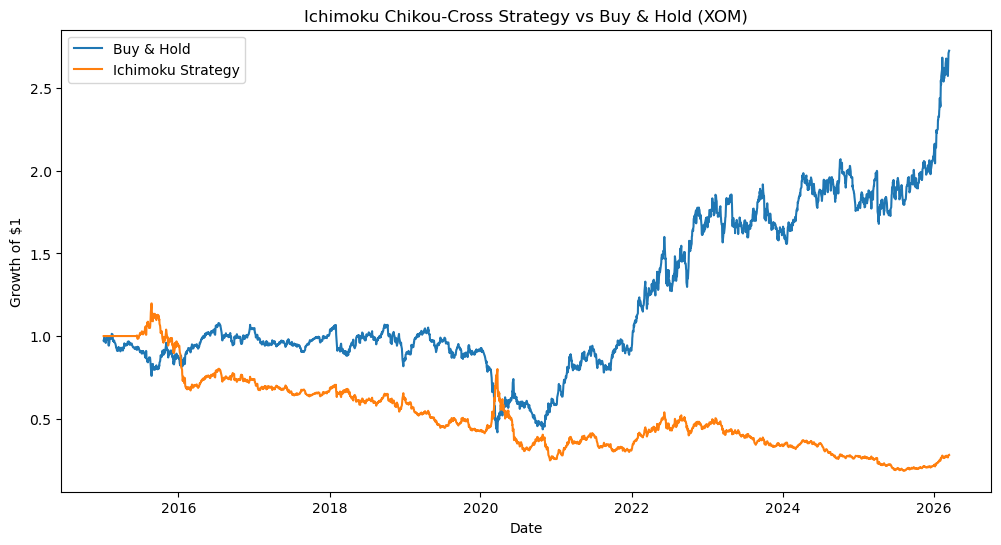

In [13]:
# visualize the comparison between the strategies
plt.figure(figsize=(12,6))

plt.plot(bt.index, bt["cum_asset"], label="Buy & Hold")
plt.plot(bt.index, bt["cum_strategy"], label="Ichimoku Strategy")

plt.title("Ichimoku Chikou-Cross Strategy vs Buy & Hold (XOM)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()

plt.show()

In [14]:
# use valid returns only
asset_ret_clean = asset_ret.dropna()
strategy_ret_clean = strategy_ret.dropna()

# use valid cumulative values only
cum_asset_clean = cum_asset.dropna()
cum_strategy_clean = cum_strategy.dropna()

# total return
total_asset_return = cum_asset_clean.iloc[-1] - 1
total_strategy_return = cum_strategy_clean.iloc[-1] - 1

# annualized return
n_days = len(asset_ret_clean)
ann_asset_return = (cum_asset_clean.iloc[-1]) ** (252 / n_days) - 1
ann_strategy_return = (cum_strategy_clean.iloc[-1]) ** (252 / n_days) - 1

# annualized volatility
asset_vol = asset_ret_clean.std() * np.sqrt(252)
strategy_vol = strategy_ret_clean.std() * np.sqrt(252)

# sharpe ratio
asset_sharpe = ann_asset_return / asset_vol
strategy_sharpe = ann_strategy_return / strategy_vol

print("===== Performance Summary =====")

print(f"Buy & Hold Total Return: {total_asset_return*100:.2f}%")
print(f"Strategy Total Return: {total_strategy_return*100:.2f}%")

print("\nAnnualized Return:")
print(f"Buy & Hold: {ann_asset_return*100:.2f}%")
print(f"Strategy: {ann_strategy_return*100:.2f}%")

print("\nAnnualized Volatility:")
print(f"Buy & Hold: {asset_vol*100:.2f}%")
print(f"Strategy: {strategy_vol*100:.2f}%")

print("\nSharpe Ratio:")
print(f"Buy & Hold: {asset_sharpe:.2f}")
print(f"Strategy: {strategy_sharpe:.2f}")

===== Performance Summary =====
Buy & Hold Total Return: 172.78%
Strategy Total Return: -71.97%

Annualized Return:
Buy & Hold: 9.40%
Strategy: -10.76%

Annualized Volatility:
Buy & Hold: 27.45%
Strategy: 27.24%

Sharpe Ratio:
Buy & Hold: 0.34
Strategy: -0.40


## 5. Backtest (on an equal-weight portfolio)

In [15]:
# create an equal-weight buy&hold benchmark
prices = data["Close"]
print(prices.head())

returns = prices.pct_change(fill_method=None).dropna()
print(returns.head())

# create an equal-weight buy&hold benchmark
portfolio_ret = returns.mean(axis=1)
cum_portfolio = (1 + portfolio_ret).cumprod()

Ticker            COP        CVX        EOG        KMI        MPC        PSX  \
Date                                                                           
2015-01-02  47.917255  69.529381  66.832115  24.255985  32.555973  47.927784   
2015-01-05  45.636806  66.750175  62.803635  23.598734  31.650047  45.030514   
2015-01-06  43.752663  66.719307  61.014019  23.134123  31.337427  43.770821   
2015-01-07  44.044666  66.663719  60.629982  23.440086  31.596767  43.963074   
2015-01-08  45.143162  68.189201  62.948521  23.989681  32.339264  45.673603   

Ticker            SLB        VLO        WMB        XOM  
Date                                                    
2015-01-02  62.534634  32.627354  24.092255  57.533424  
2015-01-05  60.841137  31.285686  23.138569  55.959206  
2015-01-06  59.651344  30.903294  22.824240  55.661720  
2015-01-07  59.644035  30.663471  22.701694  56.225704  
2015-01-08  60.366684  32.419922  22.920130  57.161556  
Ticker           COP       CVX       EOG

In [16]:
strategy_returns = pd.DataFrame(index=prices.index)

In [17]:
for symbol in symbols:

    df_symbol = data.xs(symbol, axis=1, level=1).copy()

    ichi = ichimoku(df_symbol)
    signal = make_signal_chikou(ichi)

    asset_ret = df_symbol["Close"].pct_change(fill_method=None)
    strat_ret = signal.shift(1) * asset_ret

    strategy_returns[symbol] = strat_ret

In [18]:
portfolio_strategy_ret = strategy_returns.mean(axis=1)
cum_strategy_portfolio = (1 + portfolio_strategy_ret).cumprod()

In [28]:
# compute equal-weight benchmark
prices = data["Close"][symbols]
returns = prices.pct_change(fill_method=None).dropna()

portfolio_ret = returns.mean(axis=1)
cum_portfolio = (1 + portfolio_ret).cumprod()

In [26]:
# compute the XLE benchmark
xle_prices = data["Close"]["XLE"]
xle_ret = xle_prices.pct_change(fill_method=None)
cum_xle = (1 + xle_ret).cumprod()

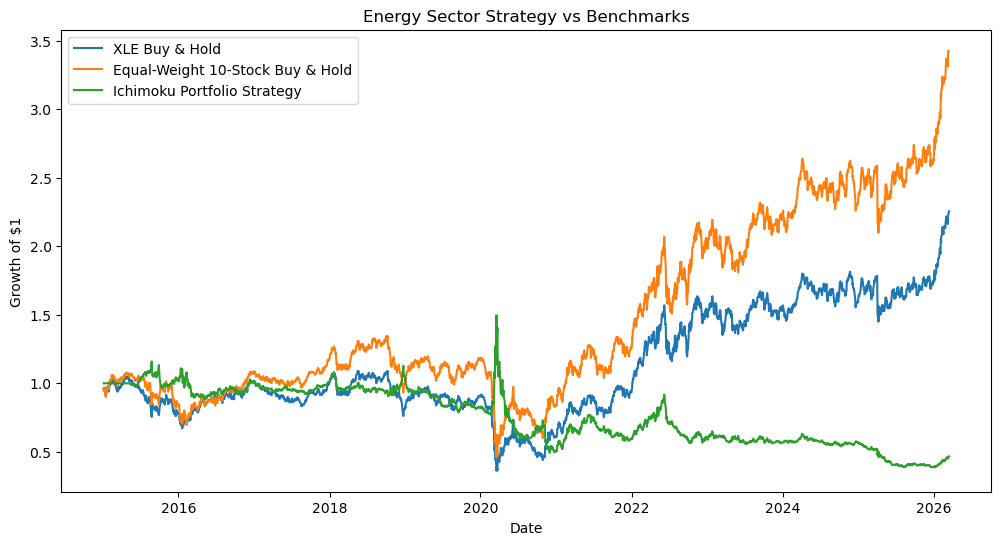

In [29]:
plt.figure(figsize=(12,6))

plt.plot(cum_xle, label="XLE Buy & Hold")
plt.plot(cum_portfolio, label="Equal-Weight 10-Stock Buy & Hold")
plt.plot(cum_strategy_portfolio, label="Ichimoku Portfolio Strategy")

plt.title("Energy Sector Strategy vs Benchmarks")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

In [30]:
def compute_drawdown(cum_returns):
    rolling_max = cum_returns.cummax()
    drawdown = cum_returns / rolling_max - 1
    return drawdown

In [ ]:
dd_xle = compute_drawdown(cum_xle)
dd_portfolio = compute_drawdown(cum_portfolio)
dd_strategy = compute_drawdown(cum_strategy_portfolio)

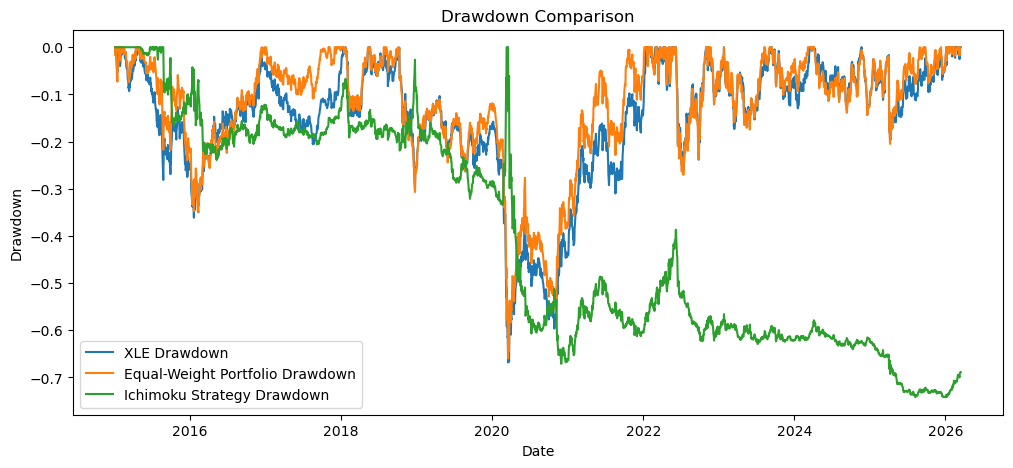

In [32]:
plt.figure(figsize=(12,5))

plt.plot(dd_xle, label="XLE Drawdown")
plt.plot(dd_portfolio, label="Equal-Weight Portfolio Drawdown")
plt.plot(dd_strategy, label="Ichimoku Strategy Drawdown")

plt.title("Drawdown Comparison")
plt.ylabel("Drawdown")
plt.xlabel("Date")

plt.legend()
plt.show()

In [ ]:
# portfolio returns
bh_ret = portfolio_ret.dropna()
strat_ret = portfolio_strategy_ret.dropna()

# total return
bh_total = cum_portfolio.iloc[-1] - 1
strat_total = cum_strategy_portfolio.iloc[-1] - 1

# annualized return
bh_ann = (cum_portfolio.iloc[-1]) ** (252 / len(bh_ret)) - 1
strat_ann = (cum_strategy_portfolio.iloc[-1]) ** (252 / len(strat_ret)) - 1

# annualized volatility
bh_vol = bh_ret.std() * np.sqrt(252)
strat_vol = strat_ret.std() * np.sqrt(252)

# Sharpe ratio (risk-free rate assumed to be zero)
bh_sharpe = bh_ann / bh_vol
strat_sharpe = strat_ann / strat_vol

# drawdowns
xle_drawdown = cum_xle / cum_xle.cummax() - 1
bh_drawdown = cum_portfolio / cum_portfolio.cummax() - 1
strat_drawdown = cum_strategy_portfolio / cum_strategy_portfolio.cummax() - 1

xle_max_dd = xle_drawdown.min()
bh_max_dd = bh_drawdown.min()
strat_max_dd = strat_drawdown.min()

In [34]:
print("===== Portfolio Performance Summary =====")

print(f"Total Return:")
print(f"Buy & Hold: {bh_total*100:.2f}%")
print(f"Strategy : {strat_total*100:.2f}%")

print("\nAnnualized Return:")
print(f"Buy & Hold: {bh_ann*100:.2f}%")
print(f"Strategy : {strat_ann*100:.2f}%")

print("\nAnnualized Volatility:")
print(f"Buy & Hold: {bh_vol*100:.2f}%")
print(f"Strategy : {strat_vol*100:.2f}%")

print("\nSharpe Ratio:")
print(f"Buy & Hold: {bh_sharpe:.2f}")
print(f"Strategy : {strat_sharpe:.2f}")

print("\nMax Drawdown:")
print(f"XLE Benchmark : {xle_max_dd*100:.2f}%")
print(f"Buy & Hold    : {bh_max_dd*100:.2f}%")
print(f"Strategy      : {strat_max_dd*100:.2f}%")

===== Portfolio Performance Summary =====
Total Return:
Buy & Hold: 242.60%
Strategy : -53.38%

Annualized Return:
Buy & Hold: 11.66%
Strategy : -6.60%

Annualized Volatility:
Buy & Hold: 29.55%
Strategy : 24.45%

Sharpe Ratio:
Buy & Hold: 0.39
Strategy : -0.27

Max Drawdown:
XLE Benchmark : -66.81%
Buy & Hold    : -65.97%
Strategy      : -74.18%


In [23]:
# making a table for presentation
summary = pd.DataFrame({
    "Metric": [
        "Total Return",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Max Drawdown"
    ],
    "Buy & Hold": [
        bh_total,
        bh_ann,
        bh_vol,
        bh_sharpe,
        bh_max_dd
    ],
    "Strategy": [
        strat_total,
        strat_ann,
        strat_vol,
        strat_sharpe,
        strat_max_dd
    ]
})

summary

,Metric,Buy & Hold,Strategy
0,Total Return,2.437767,-0.533823
1,Annualized Return,0.116883,-0.066039
2,Annualized Volatility,0.295498,0.244496
3,Sharpe Ratio,0.395545,-0.270104
4,Max Drawdown,-0.659696,-0.741844


## 6. Strategy evaluation

The Ichimoku Chikou-cross strategy underperforms the buy-and-hold benchmark in both the single-stock and portfolio backtests. While the energy benchmark generates strong long-term growth, the strategy delivers substantially weaker performance and, in some cases, negative cumulative return.

In addition, the strategy does not provide a meaningful improvement in risk-adjusted performance. Its volatility is not materially lower than the benchmark, and its Sharpe ratio is worse. Taken together, these results indicate that the strategy is not effective as a standalone trading rule for this energy-sector sample and does not outperform a passive benchmark.